In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [8]:
df = pd.read_csv("../data/raw/nav_history.csv")

df.head()

,Date,Scheme,NAV
0,2022-01-01,Scheme_01,50.17
1,2022-01-02,Scheme_01,50.15
2,2022-01-03,Scheme_01,50.36
3,2022-01-04,Scheme_01,50.84
4,2022-01-05,Scheme_01,50.79


In [9]:
df["Date"] = pd.to_datetime(df["Date"])

In [10]:
df = df.sort_values(["Scheme","Date"])

In [11]:
df["daily_return"] = df.groupby("Scheme")["NAV"].pct_change()

In [6]:
df.head(10)

,Date,Scheme,NAV,daily_return
0,2022-01-01,Scheme_01,50.17,NaN
1,2022-01-02,Scheme_01,50.15,-0.000399
2,2022-01-03,Scheme_01,50.36,0.004187
3,2022-01-04,Scheme_01,50.84,0.009531
4,2022-01-05,Scheme_01,50.79,-0.000983
5,2022-01-06,Scheme_01,50.74,-0.000984
6,2022-01-07,Scheme_01,51.23,0.009657
7,2022-01-08,Scheme_01,51.48,0.004880
8,2022-01-09,Scheme_01,51.36,-0.002331
9,2022-01-10,Scheme_01,51.54,0.003505


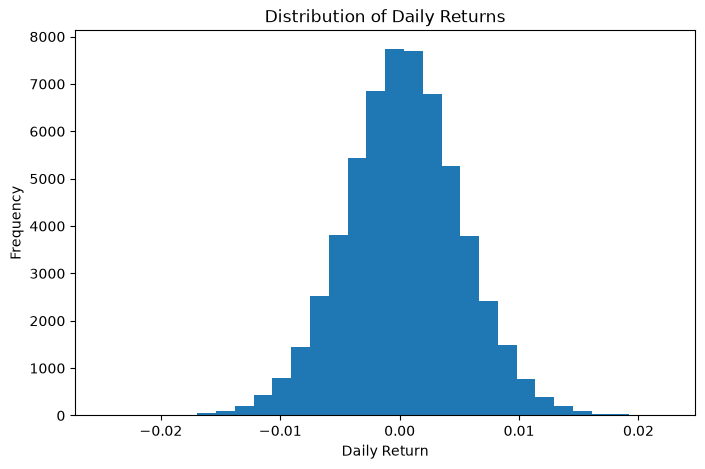

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["daily_return"].dropna(), bins=30)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()


In [13]:
def calculate_cagr(start_nav, end_nav, years):
    return (end_nav/start_nav)**(1/years)-1

In [9]:
cagr_list=[]

for scheme,group in df.groupby("Scheme"):

    start=group.iloc[0]["NAV"]
    end=group.iloc[-1]["NAV"]

    years=(group["Date"].max()-group["Date"].min()).days/365

    cagr=calculate_cagr(start,end,years)

    cagr_list.append([scheme,cagr])

cagr_df=pd.DataFrame(cagr_list,
                     columns=["Scheme","CAGR"])

cagr_df

,Scheme,CAGR
0,Scheme_01,0.185067
1,Scheme_02,0.152678
2,Scheme_03,0.056821
3,Scheme_04,0.070429
4,Scheme_05,0.079403
5,Scheme_06,0.165310
6,Scheme_07,0.095215
7,Scheme_08,0.091080
8,Scheme_09,0.136879
9,Scheme_10,0.166260


In [10]:
rf=0.065

sharpe=[]

for scheme,group in df.groupby("Scheme"):

    r=group["daily_return"].dropna()

    sr=((r.mean()*252)-rf)/(r.std()*np.sqrt(252))

    sharpe.append([scheme,sr])

sharpe_df=pd.DataFrame(sharpe,
columns=["Scheme","Sharpe"])

sharpe_df=sharpe_df.sort_values("Sharpe",
ascending=False)

sharpe_df

,Scheme,Sharpe
27,Scheme_28,0.990350
0,Scheme_01,0.756076
11,Scheme_12,0.679695
9,Scheme_10,0.631630
17,Scheme_18,0.594305
30,Scheme_31,0.567232
5,Scheme_06,0.561756
1,Scheme_02,0.509664
20,Scheme_21,0.495793
26,Scheme_27,0.461585


In [11]:
sortino=[]

for scheme,group in df.groupby("Scheme"):

    r=group["daily_return"].dropna()

    downside=r[r<0]

    ratio=((r.mean()*252)-rf)/(downside.std()*np.sqrt(252))

    sortino.append([scheme,ratio])

sortino_df=pd.DataFrame(sortino,
columns=["Scheme","Sortino"])

sortino_df

,Scheme,Sortino
0,Scheme_01,1.295882
1,Scheme_02,0.859873
2,Scheme_03,-0.470065
3,Scheme_04,-0.305937
4,Scheme_05,-0.167615
5,Scheme_06,0.940598
6,Scheme_07,0.012698
7,Scheme_08,-0.033586
8,Scheme_09,0.585882
9,Scheme_10,1.084034


In [12]:
drawdowns=[]

for scheme,group in df.groupby("Scheme"):

    running_max=group["NAV"].cummax()

    dd=group["NAV"]/running_max-1

    drawdowns.append([scheme,dd.min()])

drawdown_df=pd.DataFrame(drawdowns,
columns=["Scheme","Max_Drawdown"])

drawdown_df

,Scheme,Max_Drawdown
0,Scheme_01,-0.082978
1,Scheme_02,-0.070267
2,Scheme_03,-0.139691
3,Scheme_04,-0.104053
4,Scheme_05,-0.140027
5,Scheme_06,-0.088409
6,Scheme_07,-0.080109
7,Scheme_08,-0.116477
8,Scheme_09,-0.090074
9,Scheme_10,-0.066316


In [31]:
import os
print(os.getcwd())

c:\Users\98moh\OneDrive\Desktop\mutual_fund_analysis\notebooks


In [32]:
import os
print(os.listdir("../data/raw"))

['aum.csv', 'category_inflow.csv', 'folio_count.csv', 'HDFC_Top100_NAV.csv', 'investors.csv', 'nav_history.csv', 'nifty100.csv', 'portfolio_holdings.csv', 'sip_inflows.csv']


In [33]:
import os

print(os.path.exists("../data/raw/nifty100.csv"))

True


In [19]:
nifty = pd.read_csv("../data/raw/nifty100.csv")
nifty.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,25-06-2026,"25,114.10","25,182.75","25,317.10","25,096.25",853.39M,0.15%
1,24-06-2026,"25,075.95","24,880.70","25,148.35","24,872.70",756.17M,0.68%
2,23-06-2026,"24,907.80","25,182.55","25,230.45","24,867.45",887.07M,-1.20%
3,22-06-2026,"25,209.55","25,182.60","25,238.95","25,147.00",621.62M,0.49%
4,19-06-2026,"25,086.65","25,071.45","25,120.00","24,969.00",979.66M,-0.58%


In [34]:
nifty["Date"] = pd.to_datetime(nifty["Date"], dayfirst=True)

nifty["Price"] = (
    nifty["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

nifty = nifty.sort_values("Date")

nifty["daily_return"] = nifty["Price"].pct_change()

nifty.head()

,Date,Price,Open,High,Low,Vol.,Change %,daily_return
19,2026-05-29,24608.45,"24,992.40","25,082.10","24,544.95",1.84B,-1.45%,NaN
18,2026-06-01,24393.05,"24,722.30","24,789.75","24,369.85",702.62M,-0.88%,-0.008753
17,2026-06-02,24491.30,"24,234.15","24,555.60","24,217.40",817.80M,0.40%,0.004028
16,2026-06-03,24408.30,"24,435.50","24,467.05","24,146.30",707.39M,-0.34%,-0.003389
15,2026-06-04,24427.70,"24,291.90","24,486.80","24,255.40",639.25M,0.08%,0.000795


In [27]:
from scipy.stats import linregress

alpha_beta = []

for scheme, group in df.groupby("Scheme"):

    merged = pd.merge(
        group[["Date", "daily_return"]],
        nifty[["Date", "daily_return"]],
        on="Date",
        suffixes=("_fund", "_benchmark")
    ).dropna()

    if len(merged) > 1:

        slope, intercept, r, p, stderr = linregress(
            merged["daily_return_benchmark"],
            merged["daily_return_fund"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append([scheme, alpha, beta])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=["Scheme", "Alpha", "Beta"]
)

alpha_beta_df.to_csv("alpha_beta.csv", index=False)

alpha_beta_df.head()

,Scheme,Alpha,Beta


In [35]:
print(df["Date"].min(), df["Date"].max())
print(nifty["Date"].min(), nifty["Date"].max())

2022-01-01 00:00:00 2025-12-31 00:00:00
2026-05-29 00:00:00 2026-06-25 00:00:00


In [36]:
print(nifty.shape)

(20, 8)


In [37]:
print(nifty.head())

         Date     Price       Open       High        Low     Vol. Change %  \
19 2026-05-29  24608.45  24,992.40  25,082.10  24,544.95    1.84B   -1.45%   
18 2026-06-01  24393.05  24,722.30  24,789.75  24,369.85  702.62M   -0.88%   
17 2026-06-02  24491.30  24,234.15  24,555.60  24,217.40  817.80M    0.40%   
16 2026-06-03  24408.30  24,435.50  24,467.05  24,146.30  707.39M   -0.34%   
15 2026-06-04  24427.70  24,291.90  24,486.80  24,255.40  639.25M    0.08%   

    daily_return  
19           NaN  
18     -0.008753  
17      0.004028  
16     -0.003389  
15      0.000795  


In [38]:
print(nifty.tail())

        Date     Price       Open       High        Low     Vol. Change %  \
4 2026-06-19  25086.65  25,071.45  25,120.00  24,969.00  979.66M   -0.58%   
3 2026-06-22  25209.55  25,182.60  25,238.95  25,147.00  621.62M    0.49%   
2 2026-06-23  24907.80  25,182.55  25,230.45  24,867.45  887.07M   -1.20%   
1 2026-06-24  25075.95  24,880.70  25,148.35  24,872.70  756.17M    0.68%   
0 2026-06-25  25114.10  25,182.75  25,317.10  25,096.25  853.39M    0.15%   

   daily_return  
4     -0.005826  
3      0.004899  
2     -0.011970  
1      0.006751  
0      0.001521  


In [39]:
nifty["Date"] = pd.to_datetime(nifty["Date"], dayfirst=True)

nifty["Price"] = (
    nifty["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

nifty = nifty.sort_values("Date")

nifty["daily_return"] = nifty["Price"].pct_change()

nifty.head()

,Date,Price,Open,High,Low,Vol.,Change %,daily_return
19,2026-05-29,24608.45,"24,992.40","25,082.10","24,544.95",1.84B,-1.45%,NaN
18,2026-06-01,24393.05,"24,722.30","24,789.75","24,369.85",702.62M,-0.88%,-0.008753
17,2026-06-02,24491.30,"24,234.15","24,555.60","24,217.40",817.80M,0.40%,0.004028
16,2026-06-03,24408.30,"24,435.50","24,467.05","24,146.30",707.39M,-0.34%,-0.003389
15,2026-06-04,24427.70,"24,291.90","24,486.80","24,255.40",639.25M,0.08%,0.000795


In [40]:
from scipy.stats import linregress

alpha_beta = []

for scheme, group in df.groupby("Scheme"):

    merged = pd.merge(
        group[["Date", "daily_return"]],
        nifty[["Date", "daily_return"]],
        on="Date",
        suffixes=("_fund", "_benchmark")
    ).dropna()

    if len(merged) > 1:

        slope, intercept, r, p, stderr = linregress(
            merged["daily_return_benchmark"],
            merged["daily_return_fund"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append([scheme, alpha, beta])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=["Scheme", "Alpha", "Beta"]
)

alpha_beta_df.to_csv("alpha_beta.csv", index=False)

alpha_beta_df.head()

,Scheme,Alpha,Beta


In [41]:
nifty = pd.read_csv("../data/raw/nifty100.csv")

print(nifty.head(10))
print(nifty.tail(10))
print("Rows:", len(nifty))

         Date      Price       Open       High        Low     Vol. Change %
0  31-12-2025  26,689.30  26,520.80  26,744.40  26,519.10  458.50M    0.78%
1  30-12-2025  26,482.55  26,479.85  26,522.40  26,411.50  673.28M    0.00%
2  29-12-2025  26,483.45  26,612.35  26,641.90  26,460.05  498.86M   -0.40%
3  26-12-2025  26,589.35  26,658.50  26,692.15  26,551.70  429.74M   -0.32%
4  24-12-2025  26,674.50  26,713.75  26,773.25  26,653.05  351.48M   -0.14%
5  23-12-2025  26,713.15  26,734.05  26,766.60  26,650.25  414.70M    0.07%
6  22-12-2025  26,693.20  26,579.40  26,701.75  26,565.30  432.45M    0.77%
7  19-12-2025  26,488.00  26,414.20  26,500.30  26,391.40  580.44M    0.62%
8  18-12-2025  26,324.65  26,295.45  26,410.90  26,222.45  354.64M   -0.07%
9  17-12-2025  26,342.65  26,435.85  26,472.30  26,291.65  403.07M   -0.20%
           Date      Price       Open       High        Low     Vol. Change %
982  14-01-2022  18,485.70  18,411.20  18,515.10  18,348.40  454.77M    0.02%
983  13-

In [1]:
import pandas as pd

In [2]:
nifty = pd.read_csv("../data/raw/nifty100.csv")

In [3]:
nifty["Date"] = pd.to_datetime(nifty["Date"], dayfirst=True)

In [4]:
print(nifty["Date"].min())
print(nifty["Date"].max())

2022-01-03 00:00:00
2025-12-31 00:00:00


In [5]:
nifty["Price"] = (
    nifty["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

nifty = nifty.sort_values("Date")

nifty["daily_return"] = nifty["Price"].pct_change()

In [14]:
from scipy.stats import linregress

alpha_beta = []

for scheme, group in df.groupby("Scheme"):

    merged = pd.merge(
        group[["Date", "daily_return"]],
        nifty[["Date", "daily_return"]],
        on="Date",
        suffixes=("_fund", "_benchmark")
    ).dropna()

    if len(merged) > 1:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["daily_return_benchmark"],
            merged["daily_return_fund"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append([scheme, alpha, beta])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=["Scheme", "Alpha", "Beta"]
)

alpha_beta_df.to_csv("alpha_beta.csv", index=False)

alpha_beta_df.head()

,Scheme,Alpha,Beta
0,Scheme_01,0.099193,-0.005539
1,Scheme_02,0.108991,0.008095
2,Scheme_03,0.061125,-0.010034
3,Scheme_04,0.015940,0.023967
4,Scheme_05,0.060281,0.007212


In [15]:
print(df.columns)

Index(['Date', 'Scheme', 'NAV', 'daily_return'], dtype='object')


In [17]:
print(df.head())

        Date     Scheme    NAV  daily_return
0 2022-01-01  Scheme_01  50.17           NaN
1 2022-01-02  Scheme_01  50.15     -0.000399
2 2022-01-03  Scheme_01  50.36      0.004187
3 2022-01-04  Scheme_01  50.84      0.009531
4 2022-01-05  Scheme_01  50.79     -0.000983


In [18]:
print(nifty.head())

          Date     Price       Open       High        Low     Vol. Change %  \
991 2022-01-03  17874.00  17,654.45  17,894.15  17,651.45  575.68M    1.45%   
990 2022-01-04  18030.95  17,934.50  18,051.50  17,831.50  674.49M    0.88%   
989 2022-01-05  18147.50  18,044.30  18,164.70  17,974.90  789.82M    0.65%   
988 2022-01-06  17985.60  17,997.60  18,025.25  17,889.75  550.86M   -0.89%   
987 2022-01-07  18053.95  18,035.70  18,140.85  17,944.40  591.47M    0.38%   

     daily_return  
991           NaN  
990      0.008781  
989      0.006464  
988     -0.008921  
987      0.003800  


In [19]:
print(alpha_beta_df.head())

      Scheme     Alpha      Beta
0  Scheme_01  0.099193 -0.005539
1  Scheme_02  0.108991  0.008095
2  Scheme_03  0.061125 -0.010034
3  Scheme_04  0.015940  0.023967
4  Scheme_05  0.060281  0.007212


In [20]:
print(df.columns)

Index(['Date', 'Scheme', 'NAV', 'daily_return'], dtype='object')


In [21]:
cagr = []

for scheme, group in df.groupby("Scheme"):

    group = group.sort_values("Date")

    start_nav = group["NAV"].iloc[0]
    end_nav = group["NAV"].iloc[-1]

    years = (group["Date"].max() - group["Date"].min()).days / 365

    cagr_value = ((end_nav / start_nav) ** (1 / years) - 1)

    cagr.append([scheme, cagr_value])

cagr_df = pd.DataFrame(cagr, columns=["Scheme", "CAGR"])

cagr_df.head()

,Scheme,CAGR
0,Scheme_01,0.185067
1,Scheme_02,0.152678
2,Scheme_03,0.056821
3,Scheme_04,0.070429
4,Scheme_05,0.079403


In [22]:
rf = 0.065

sharpe = []

for scheme, group in df.groupby("Scheme"):

    returns = group["daily_return"].dropna()

    sharpe_ratio = ((returns.mean()*252 - rf) /
                    (returns.std()* (252**0.5)))

    sharpe.append([scheme, sharpe_ratio])

sharpe_df = pd.DataFrame(sharpe, columns=["Scheme","Sharpe"])

sharpe_df.head()

,Scheme,Sharpe
0,Scheme_01,0.756076
1,Scheme_02,0.509664
2,Scheme_03,-0.283935
3,Scheme_04,-0.187428
4,Scheme_05,-0.097662


In [23]:
drawdown = []

for scheme, group in df.groupby("Scheme"):

    group = group.sort_values("Date")

    running_max = group["NAV"].cummax()

    dd = (group["NAV"] / running_max) - 1

    drawdown.append([scheme, dd.min()])

drawdown_df = pd.DataFrame(drawdown,
                           columns=["Scheme","Max_Drawdown"])

drawdown_df.head()

,Scheme,Max_Drawdown
0,Scheme_01,-0.082978
1,Scheme_02,-0.070267
2,Scheme_03,-0.139691
3,Scheme_04,-0.104053
4,Scheme_05,-0.140027


In [24]:
scorecard = cagr_df.merge(sharpe_df, on="Scheme")
scorecard = scorecard.merge(alpha_beta_df, on="Scheme")
scorecard = scorecard.merge(drawdown_df, on="Scheme")

scorecard["CAGR_Rank"] = scorecard["CAGR"].rank(ascending=False)
scorecard["Sharpe_Rank"] = scorecard["Sharpe"].rank(ascending=False)
scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)
scorecard["Drawdown_Rank"] = scorecard["Max_Drawdown"].rank(ascending=False)

scorecard["Fund_Score"] = (
    0.40 * scorecard["CAGR_Rank"] +
    0.30 * scorecard["Sharpe_Rank"] +
    0.20 * scorecard["Alpha_Rank"] +
    0.10 * scorecard["Drawdown_Rank"]
)

scorecard = scorecard.sort_values("Fund_Score")

scorecard.to_csv("fund_scorecard.csv", index=False)

scorecard.head()

,Scheme,CAGR,Sharpe,Alpha,Beta,Max_Drawdown,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Fund_Score
27,Scheme_28,0.202601,0.990350,0.142018,-0.013980,-0.074152,1.0,1.0,2.0,6.0,1.7
0,Scheme_01,0.185067,0.756076,0.099193,-0.005539,-0.082978,2.0,2.0,13.0,9.0,4.9
11,Scheme_12,0.173930,0.679695,0.091334,-0.006617,-0.071576,3.0,3.0,17.0,4.0,5.9
5,Scheme_06,0.165310,0.561756,0.124781,-0.027917,-0.088409,5.0,7.0,5.0,13.0,6.4
9,Scheme_10,0.166260,0.631630,0.087116,-0.010584,-0.066316,4.0,4.0,18.0,1.0,6.5


In [25]:
scorecard = cagr_df.merge(sharpe_df, on="Scheme")
scorecard = scorecard.merge(alpha_beta_df, on="Scheme")
scorecard = scorecard.merge(drawdown_df, on="Scheme")

In [26]:
scorecard["CAGR_Rank"] = scorecard["CAGR"].rank(ascending=False)
scorecard["Sharpe_Rank"] = scorecard["Sharpe"].rank(ascending=False)
scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)
scorecard["Drawdown_Rank"] = scorecard["Max_Drawdown"].rank(ascending=False)

In [27]:
scorecard["Fund_Score"] = (
    scorecard["CAGR_Rank"] * 0.40 +
    scorecard["Sharpe_Rank"] * 0.30 +
    scorecard["Alpha_Rank"] * 0.20 +
    scorecard["Drawdown_Rank"] * 0.10
)

In [28]:
scorecard = scorecard.sort_values("Fund_Score")

In [29]:
scorecard.to_csv("fund_scorecard.csv", index=False)

scorecard.head()

,Scheme,CAGR,Sharpe,Alpha,Beta,Max_Drawdown,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Fund_Score
27,Scheme_28,0.202601,0.990350,0.142018,-0.013980,-0.074152,1.0,1.0,2.0,6.0,1.7
0,Scheme_01,0.185067,0.756076,0.099193,-0.005539,-0.082978,2.0,2.0,13.0,9.0,4.9
11,Scheme_12,0.173930,0.679695,0.091334,-0.006617,-0.071576,3.0,3.0,17.0,4.0,5.9
5,Scheme_06,0.165310,0.561756,0.124781,-0.027917,-0.088409,5.0,7.0,5.0,13.0,6.4
9,Scheme_10,0.166260,0.631630,0.087116,-0.010584,-0.066316,4.0,4.0,18.0,1.0,6.5


In [30]:
top5 = scorecard.head(5)["Scheme"].tolist()

print(top5)

['Scheme_28', 'Scheme_01', 'Scheme_12', 'Scheme_06', 'Scheme_10']


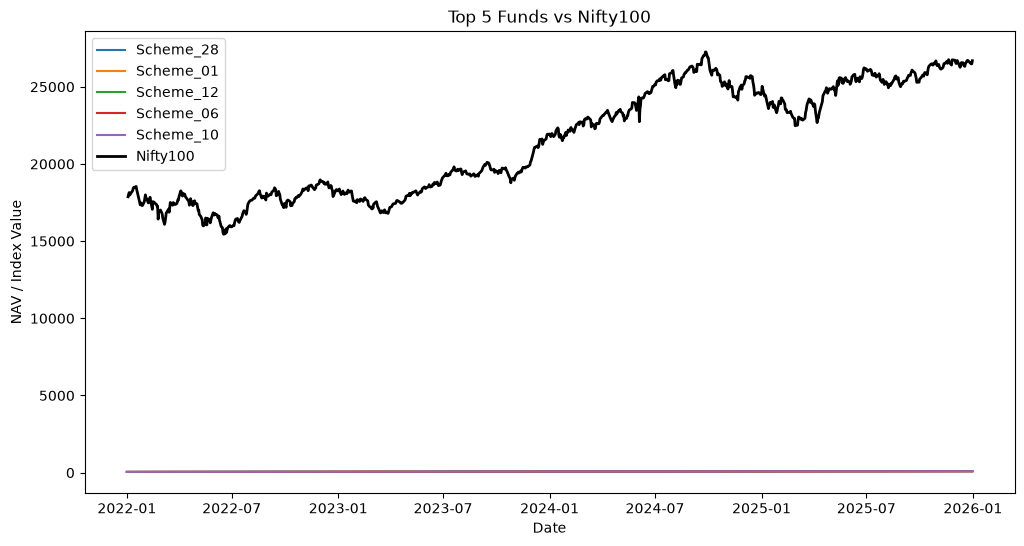

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for scheme in top5:
    temp = df[df["Scheme"] == scheme]
    plt.plot(temp["Date"], temp["NAV"], label=scheme)

plt.plot(nifty["Date"], nifty["Price"],
         color="black",
         linewidth=2,
         label="Nifty100")

plt.title("Top 5 Funds vs Nifty100")
plt.xlabel("Date")
plt.ylabel("NAV / Index Value")
plt.legend()

plt.savefig("benchmark_comparison_chart.png")

plt.show()

In [32]:
tracking_error = []

for scheme in top5:

    temp = df[df["Scheme"] == scheme]

    merged = temp.merge(
        nifty[["Date", "daily_return"]],
        on="Date",
        suffixes=("_fund", "_benchmark")
    ).dropna()

    te = (merged["daily_return_fund"] -
          merged["daily_return_benchmark"]).std() * (252**0.5)

    tracking_error.append([scheme, te])

tracking_df = pd.DataFrame(
    tracking_error,
    columns=["Scheme", "Tracking_Error"]
)

tracking_df

,Scheme,Tracking_Error
0,Scheme_28,0.153573
1,Scheme_01,0.157091
2,Scheme_12,0.156048
3,Scheme_06,0.160972
4,Scheme_10,0.154882
